In [1]:
import sys
sys.path.insert(1, './architecture')
sys.path.insert(2, './dataLoaders')
from dataloader_mapillary import *
from dataloader_cityscapes import *
import cv2 as cv
import matplotlib.pyplot as plt
import random
from pathlib import Path
from torch.utils.data import *
import torchvision
import PIL.Image as Image
from MapillaryIntendedObjs import *

In [2]:
mapil = MapillaryLoader(mode = 'validation')

In [3]:
first = mapil[31]

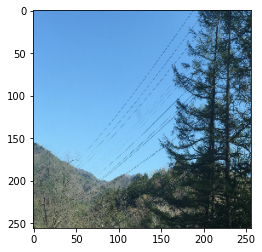

In [4]:
plt.imshow(first["image"].permute(1, 2, 0))
plt.show()

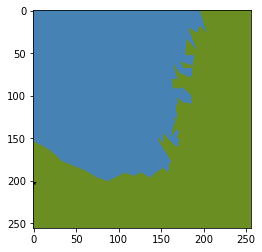

In [5]:
plt.imshow(first["seg"].permute(1, 2, 0))
plt.show()

In [6]:
first["label"][:,0,0]

tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=torch.float64)

In [7]:
city = CityscapesLoader(mode = 'val')

In [8]:
first_city = city[21]

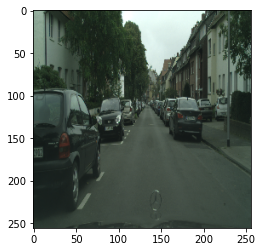

In [9]:
plt.imshow(first_city["image"].permute(1, 2, 0))
plt.show()

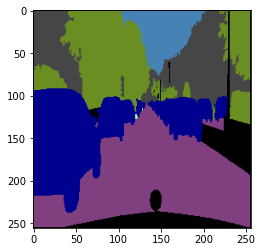

In [10]:
plt.imshow(first_city["seg"].permute(1, 2, 0))
plt.show()

In [11]:
first_city["label"][:,150,150]

tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64)

In [12]:
dataset = ConcatDataset([CityscapesLoader(), MapillaryLoader()])

In [13]:
train_loader = DataLoader(dataset = dataset, batch_size = 2, shuffle = True, drop_last = True)

In [14]:
for batch in train_loader:
    break

In [15]:
batch.keys()

dict_keys(['image', 'label', 'seg'])

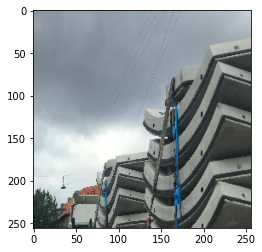

In [16]:
plt.imshow(batch["image"][1].permute(1, 2, 0))
plt.show()

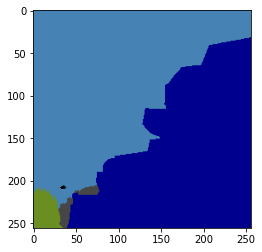

In [17]:
plt.imshow(batch["seg"][1].permute(1, 2, 0))
plt.show()

In [18]:
batch["label"][1][:,150,150]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=torch.float64)

In [19]:
convertedProbToImg = dataset.datasets[0].prMask_to_color(batch["label"])

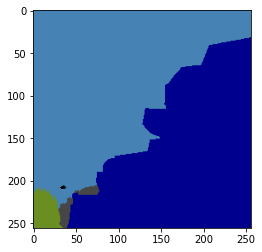

In [20]:
plt.imshow(convertedProbToImg[1].permute(1, 2, 0))
plt.show()